# Periodic FD–OPT systematic benchmarks

Boundary-free comparisons using the shared famous-equation benchmark matrix. Raw weak-residual orders include the cell-volume factor $h^d$.

In [1]:
using CairoMakie, JLD2, Statistics, LinearAlgebra

root = normpath(joinpath(@__DIR__, ".."))
datadir = joinpath(root, "scripts", "tmp", "famous_equation_periodic_benchmarks")
construction_dir = joinpath(root, "scripts", "tmp", "famous_equation_interior_diagnostics")

poisson = Dict(
    1 => load(joinpath(datadir, "poisson_fd_vs_opt_1d.jld2")),
    2 => load(joinpath(datadir, "poisson_fd_vs_opt_2d.jld2")),
)
scheme_names(d) = getproperty.(d["schemes"], :name)
case_names(d) = getproperty.(d["cases"], :name)
nothing

## Absolute and relative residual convergence

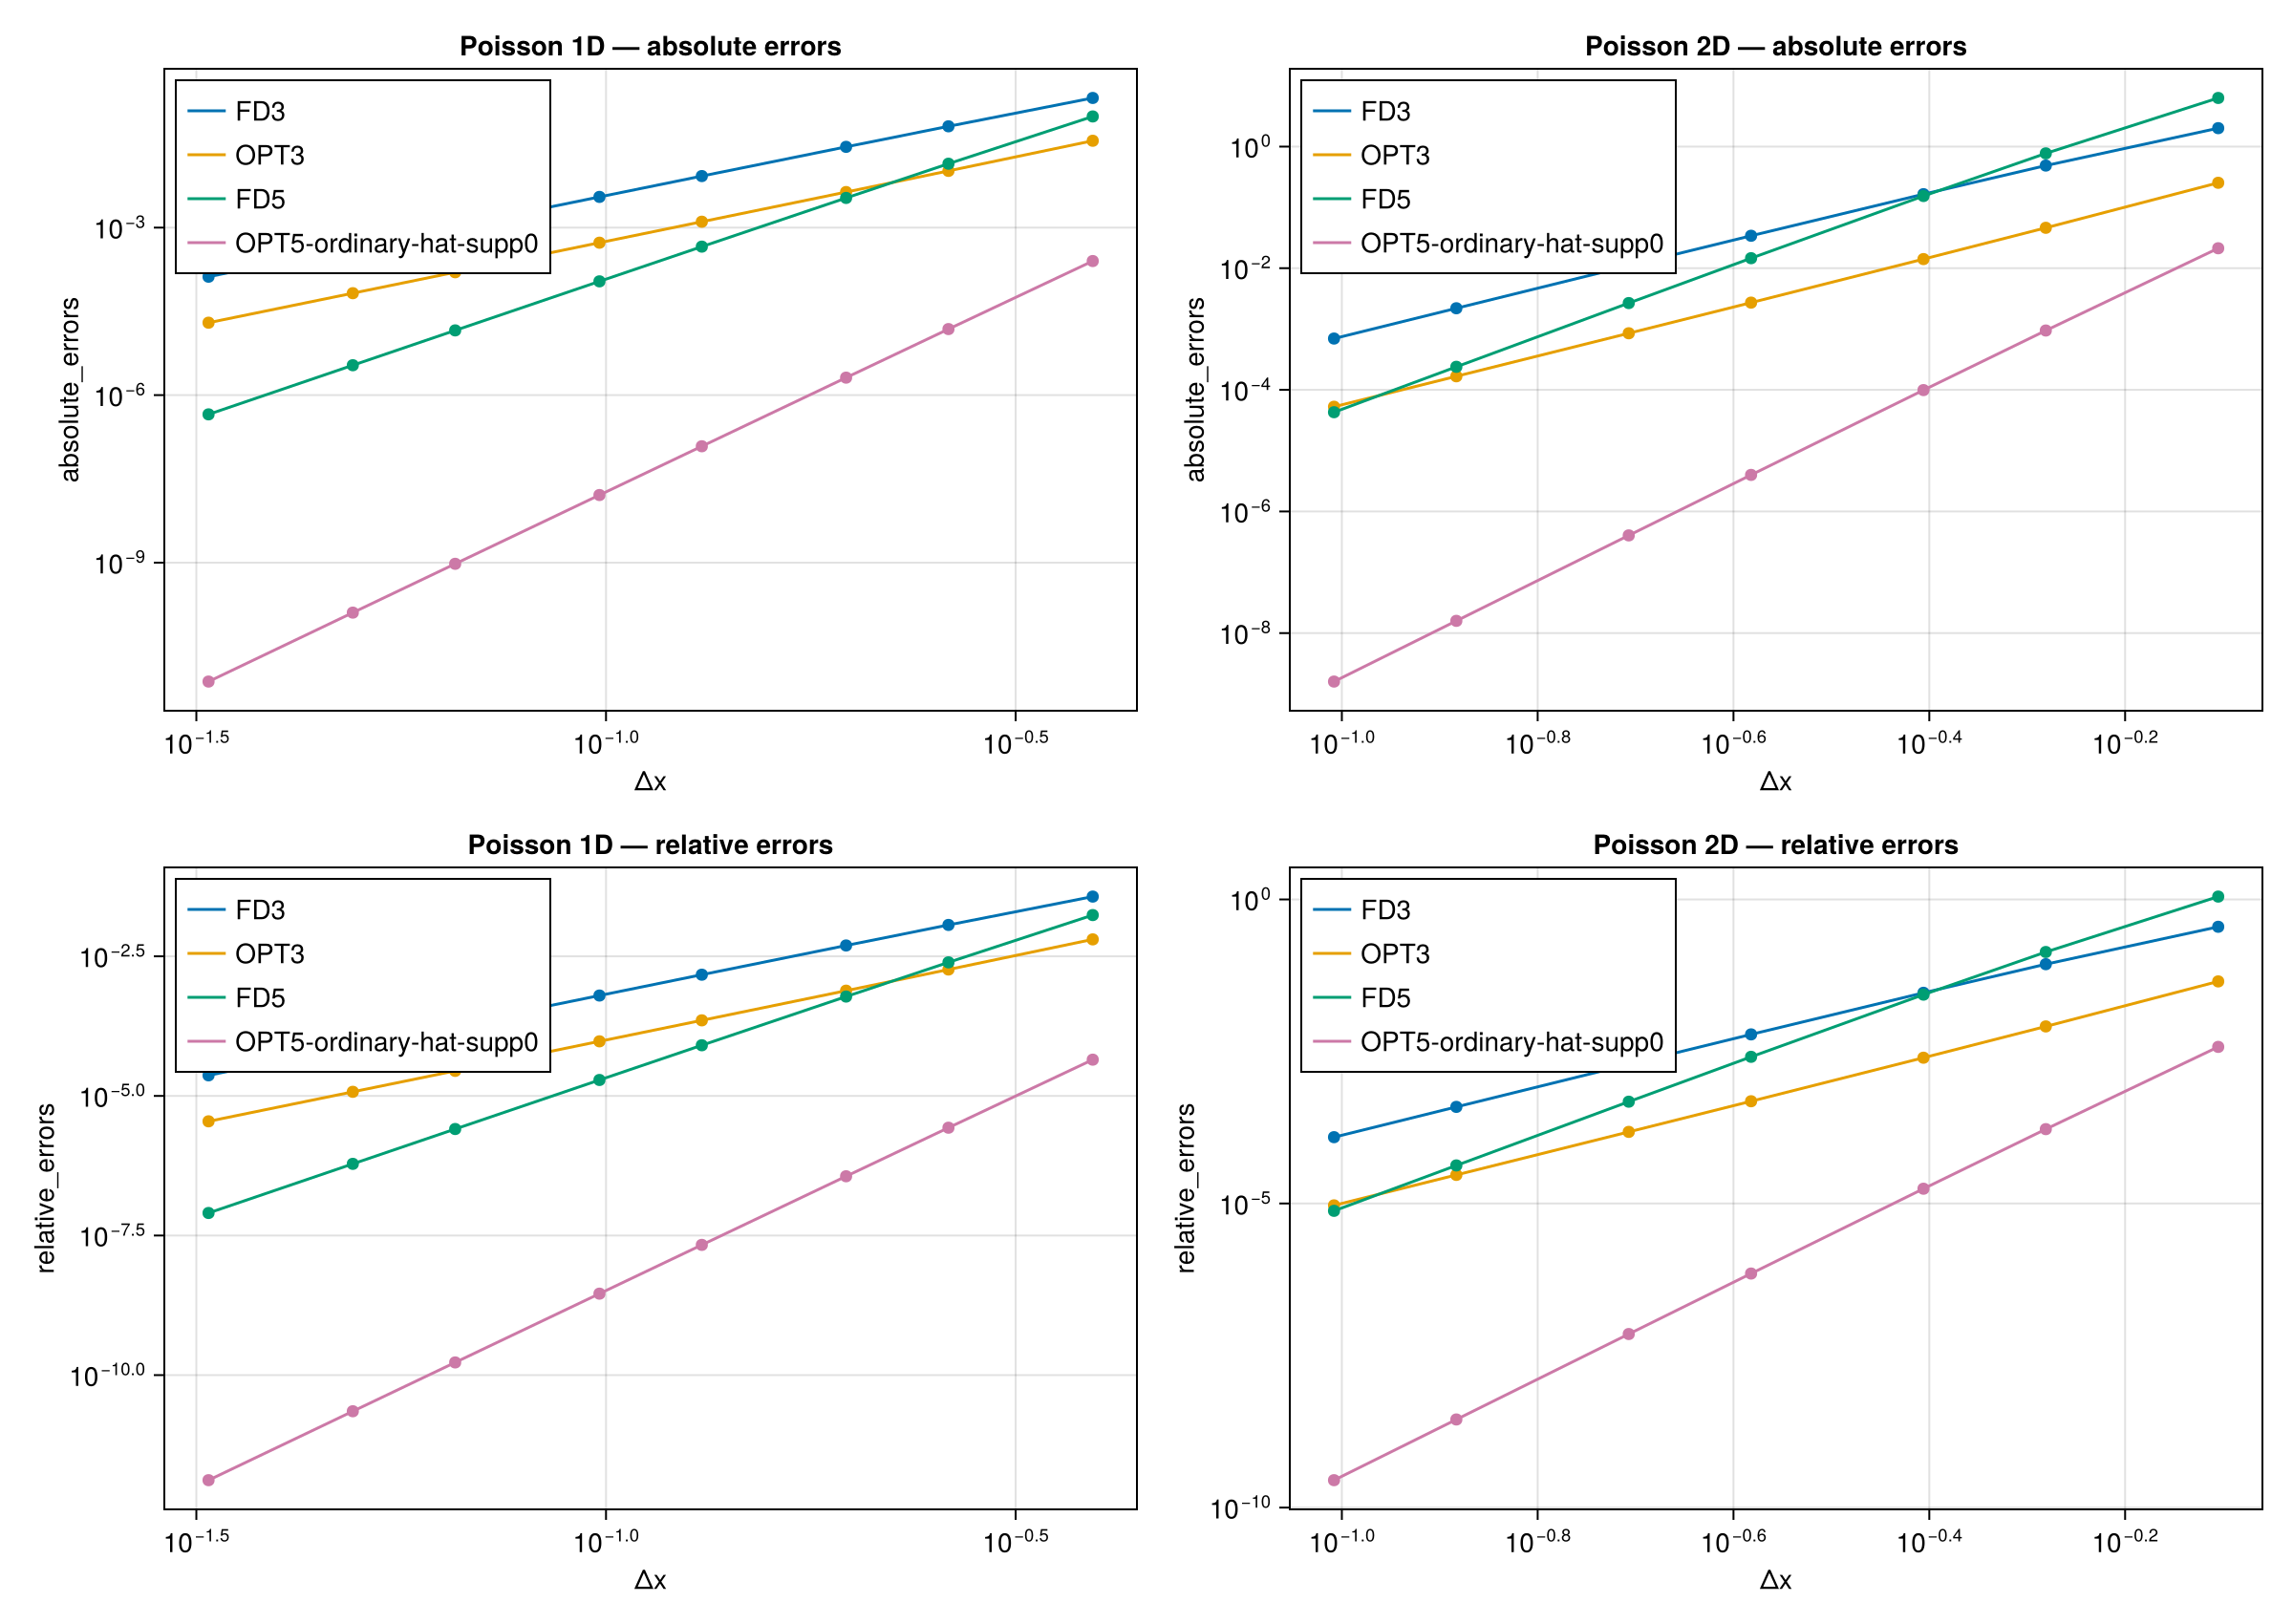

In [2]:
fig_convergence = Figure(size=(1200, 850))
for (column, dimension) in enumerate((1, 2))
    d = poisson[dimension]
    r = d["results"]["dimension_$(dimension)"]
    names = scheme_names(d)
    dx = 2π ./ r.sizes
    homogeneous = findfirst(==("homogeneous"), case_names(d))
    for (row, metric) in enumerate((:absolute_errors, :relative_errors))
        ax = Axis(fig_convergence[row, column], xscale=log10, yscale=log10,
            xlabel="Δx", ylabel=string(metric),
            title="Poisson $(dimension)D — $(replace(string(metric), "_" => " "))")
        values = getproperty(r, metric)
        for scheme in eachindex(names)
            lines!(ax, dx, values[:, homogeneous, scheme], label=names[scheme])
            scatter!(ax, dx, values[:, homogeneous, scheme])
        end
        axislegend(ax, position=:lt)
    end
end
fig_convergence

## Observed differential-operator order by material case

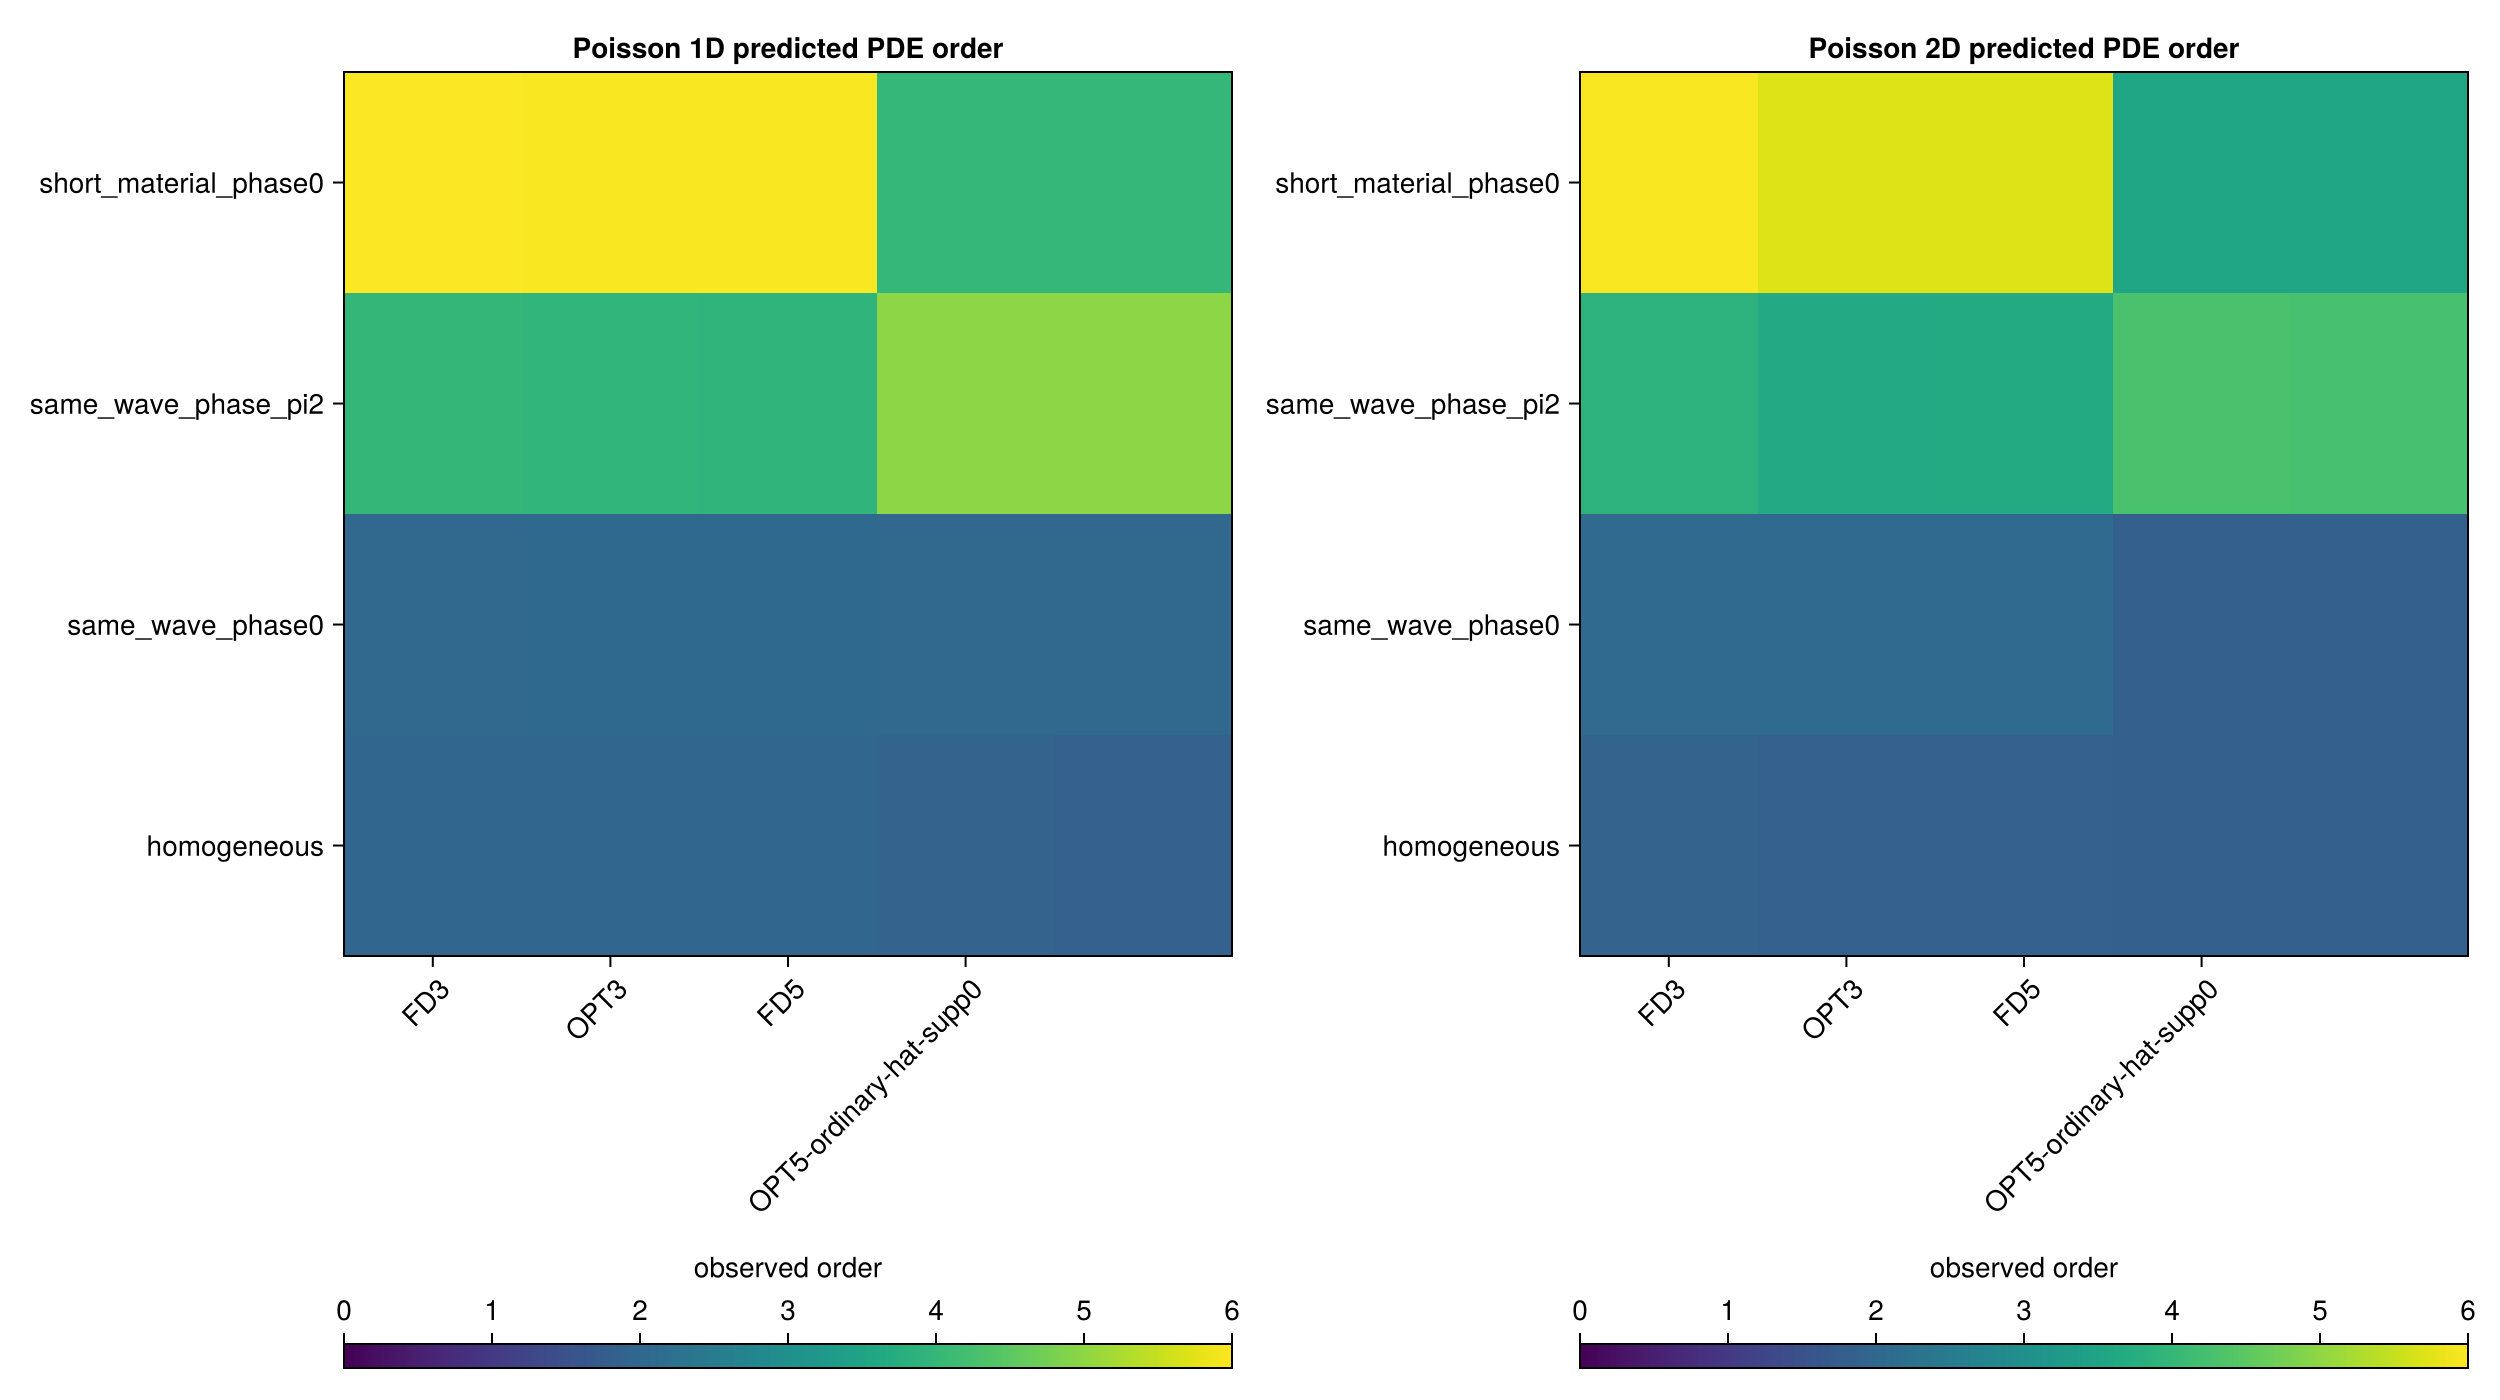

In [3]:
fig_orders = Figure(size=(1250, 700))
for (column, dimension) in enumerate((1, 2))
    d = poisson[dimension]
    r = d["results"]["dimension_$(dimension)"]
    names = scheme_names(d)
    cases = case_names(d)
    # Remove the weak cell-volume contribution h^dimension.
    order_matrix = [median(filter(isfinite, r.relative_orders[:, c, s])) - dimension
        for c in eachindex(cases), s in eachindex(names)]
    ax = Axis(fig_orders[1, column], xticks=(eachindex(names), names),
        yticks=(eachindex(cases), cases), title="Poisson $(dimension)D predicted PDE order",
        xticklabelrotation=π/4)
    hm = heatmap!(ax, order_matrix, colorrange=(0, 6))
    Colorbar(fig_orders[2, column], hm, vertical=false, label="observed order")
end
fig_orders

## OPT/FD absolute-error ratios

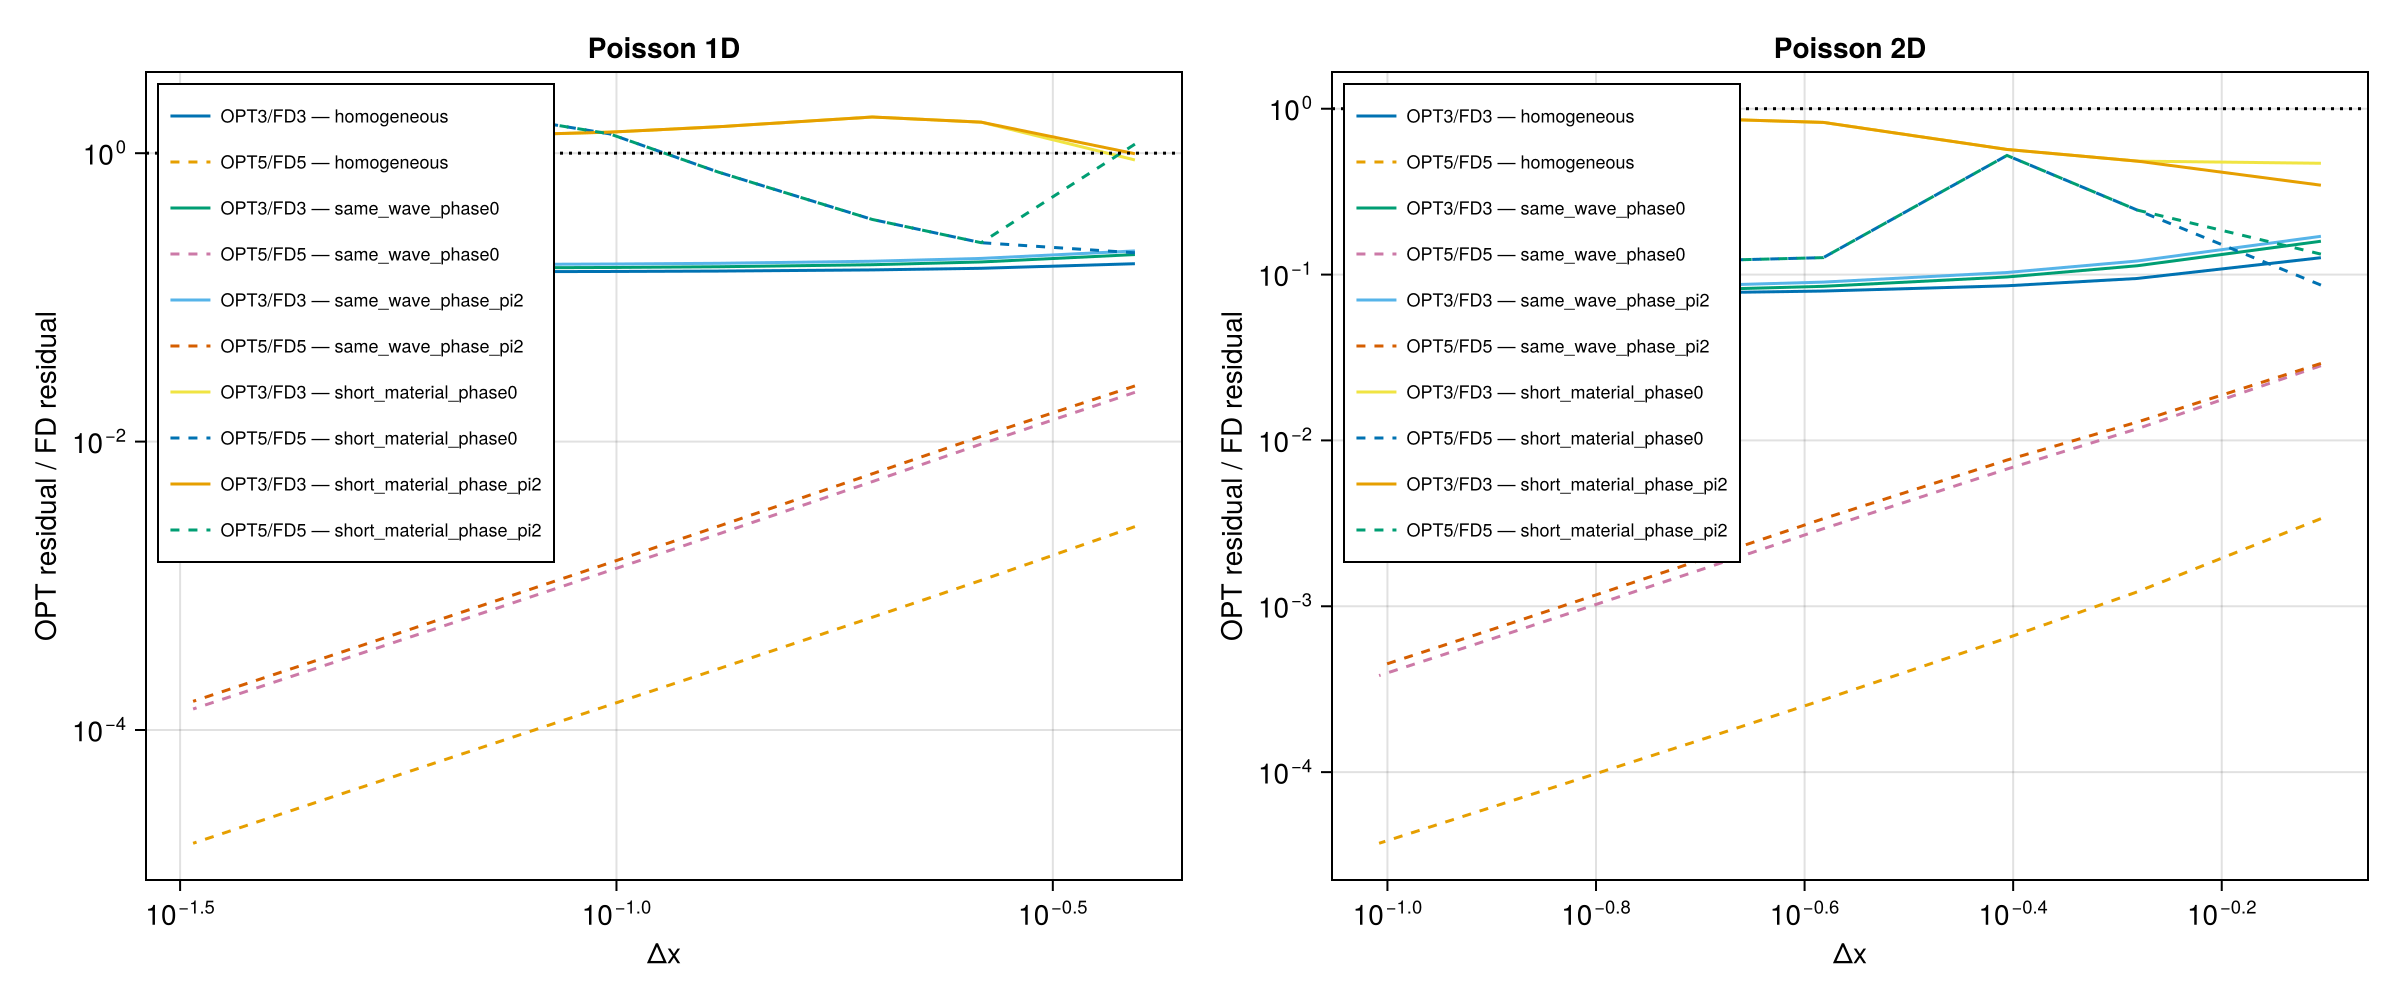

In [4]:
fig_ratios = Figure(size=(1200, 500))
for (column, dimension) in enumerate((1, 2))
    d = poisson[dimension]
    r = d["results"]["dimension_$(dimension)"]
    dx = 2π ./ r.sizes
    cases = case_names(d)
    ax = Axis(fig_ratios[1, column], xscale=log10, yscale=log10,
        xlabel="Δx", ylabel="OPT residual / FD residual",
        title="Poisson $(dimension)D")
    for case in eachindex(cases)
        lines!(ax, dx, r.relative_errors[:, case, 2] ./ r.relative_errors[:, case, 1],
            label="OPT3/FD3 — $(cases[case])")
        lines!(ax, dx, r.relative_errors[:, case, 4] ./ r.relative_errors[:, case, 3],
            linestyle=:dash, label="OPT5/FD5 — $(cases[case])")
    end
    hlines!(ax, [1.0], color=:black, linestyle=:dot)
    axislegend(ax, position=:lt, labelsize=9)
end
fig_ratios

## CPU time: recette construction and residual application

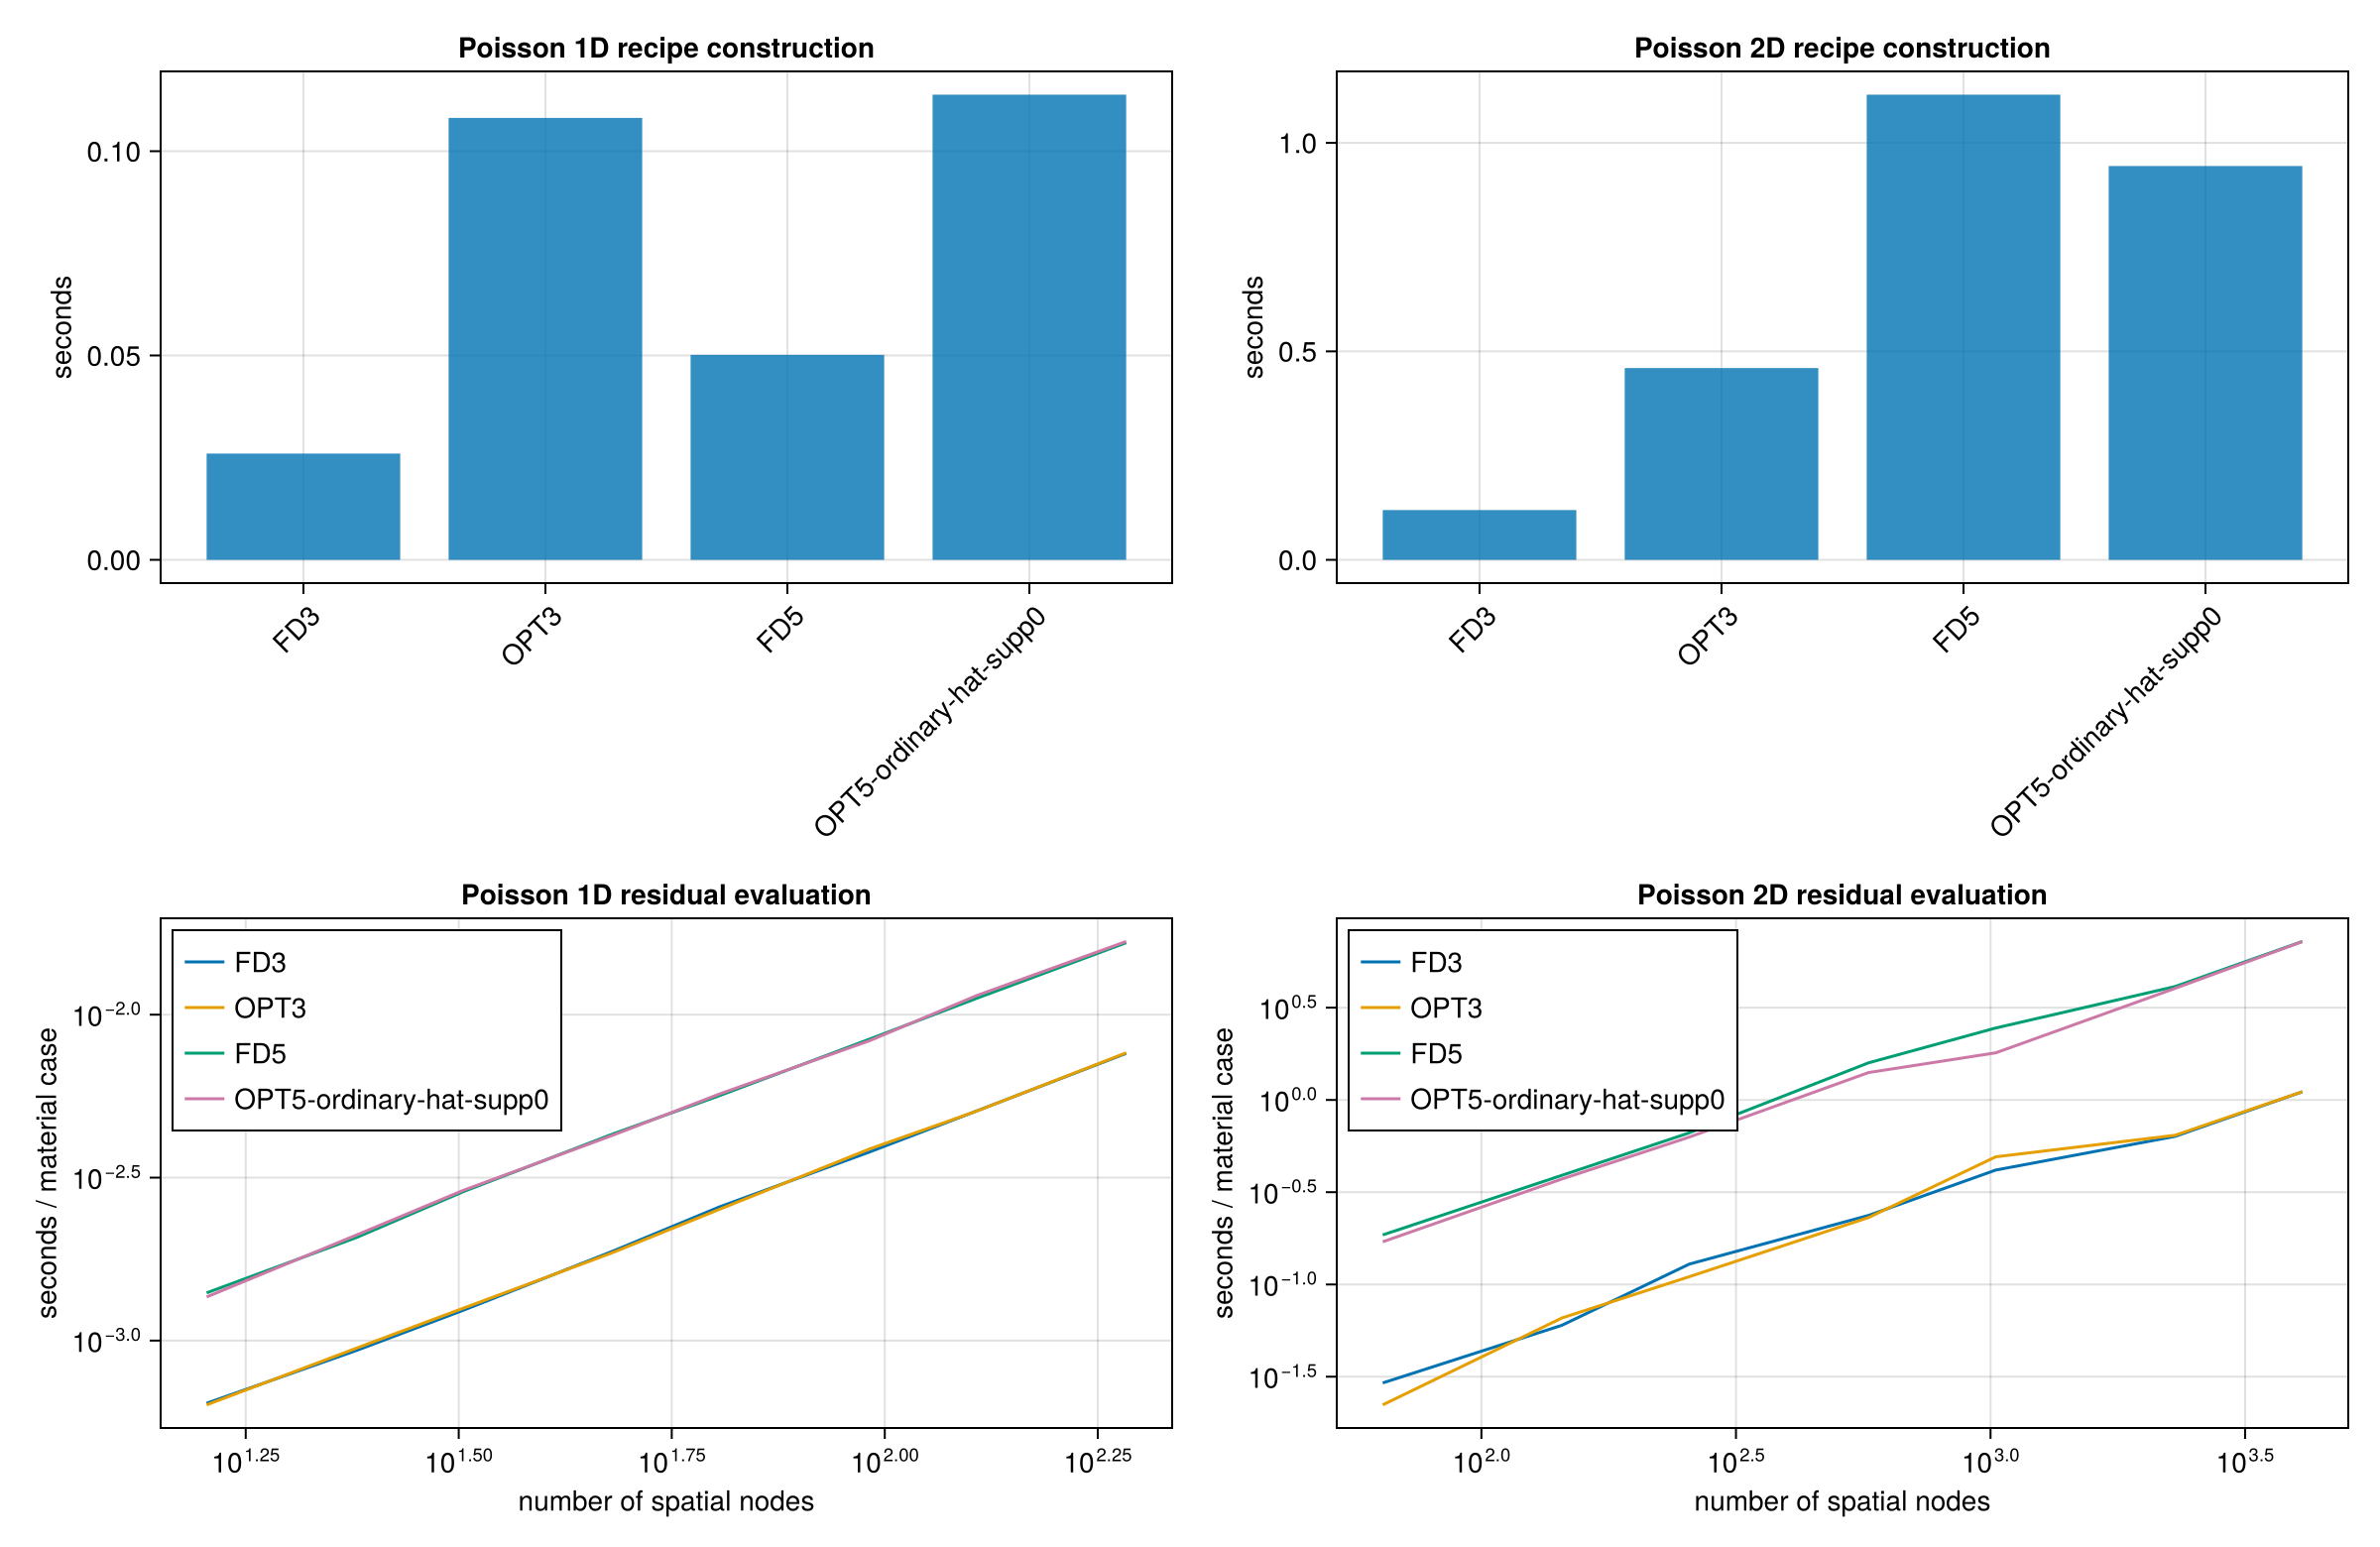

In [5]:
fig_cpu = Figure(size=(1200, 780))
for (column, dimension) in enumerate((1, 2))
    d = poisson[dimension]
    r = d["results"]["dimension_$(dimension)"]
    names = scheme_names(d)
    ax1 = Axis(fig_cpu[1, column], xticks=(eachindex(names), names),
        ylabel="seconds", title="Poisson $(dimension)D recipe construction",
        xticklabelrotation=π/4)
    barplot!(ax1, eachindex(names), [median(r.recipe_seconds[:, s]) for s in eachindex(names)])
    ax2 = Axis(fig_cpu[2, column], xscale=log10, yscale=log10,
        xlabel="number of spatial nodes", ylabel="seconds / material case",
        title="Poisson $(dimension)D residual evaluation")
    for s in eachindex(names)
        lines!(ax2, r.sizes .^ dimension,
            [median(r.residual_seconds[g, :, s]) for g in eachindex(r.sizes)], label=names[s])
    end
    axislegend(ax2, position=:lt)
end
fig_cpu

## Wave construction cost and support size

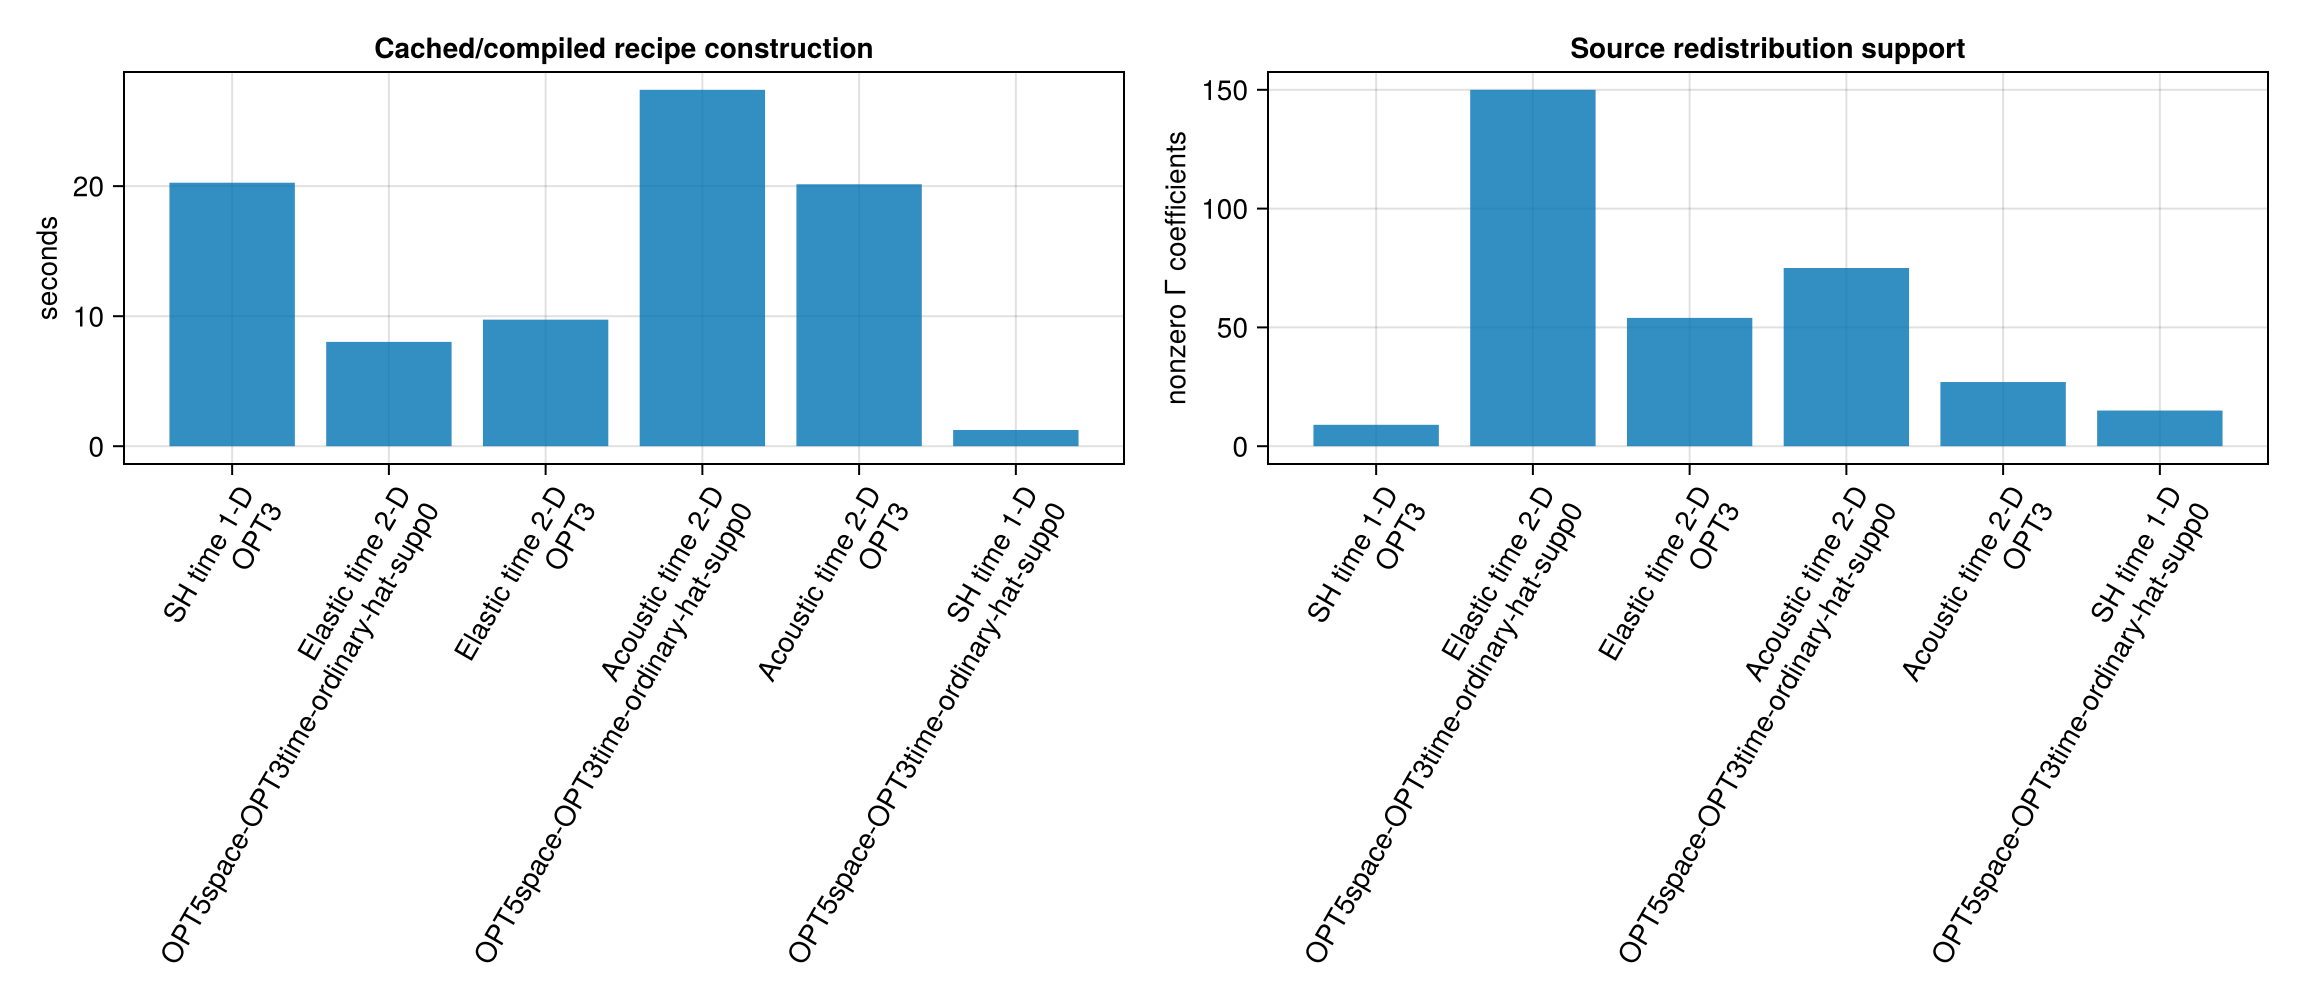

In [6]:
construction_files = filter(isfile, [
    joinpath(construction_dir, "recipe_construction_waves_max2d_time3_default.jld2"),
    joinpath(construction_dir, "recipe_construction_all_max2d_time3_default.jld2"),
])
construction_rows = reduce(vcat, [load(file)["rows"] for file in construction_files]; init=NamedTuple[])
unique_rows = Dict((row.equation, row.recipe) => row for row in construction_rows)
wave_rows = collect(values(unique_rows))
fig_wave_cost = Figure(size=(1150, 500))
labels = ["$(row.equation_label)\n$(row.recipe)" for row in wave_rows]
ax = Axis(fig_wave_cost[1, 1], xticks=(eachindex(labels), labels),
    xticklabelrotation=π/3, ylabel="seconds", title="Cached/compiled recipe construction")
barplot!(ax, eachindex(labels), getproperty.(wave_rows, :build_seconds))
ax2 = Axis(fig_wave_cost[1, 2], xticks=(eachindex(labels), labels),
    xticklabelrotation=π/3, ylabel="nonzero Γ coefficients", title="Source redistribution support")
barplot!(ax2, eachindex(labels), getproperty.(wave_rows, :gamma_nonzero))
fig_wave_cost

## CFL, dispersion and elastic P/S branches

These cells activate when `wave_fd_vs_opt.jld2` is produced by the unified wave-symbol sweep.

In [7]:
wave_file = joinpath(datadir, "wave_fd_vs_opt.jld2")
if isfile(wave_file)
    wave = load(wave_file)
    fig_cfl = Figure(size=(1100, 450))
    ax = Axis(fig_cfl[1, 1], ylabel="maximum stable CFL", title="CFL by PDE and scheme")
    # Expected schema: wave[\"cfl_rows\"] with equation, scheme, branch, cfl_max.
    rows = wave["cfl_rows"]
    labels = ["$(r.equation) $(r.scheme) $(r.branch)" for r in rows]
    ax.xticks = (eachindex(labels), labels)
    ax.xticklabelrotation = π/3
    barplot!(ax, eachindex(rows), getproperty.(rows, :cfl_max))
    fig_cfl
else
    @info "wave_fd_vs_opt.jld2 not yet present; CFL figure deferred"
end

┌ Info: wave_fd_vs_opt.jld2 not yet present; CFL figure deferred
└ @ Main /Users/nobuaki/Documents/Github/flexOPT/notebooks/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X16sZmlsZQ==.jl:14


In [8]:
if isfile(wave_file)
    wave = load(wave_file)
    rows = wave["dispersion_rows"]
    groups = unique((r.equation, r.branch) for r in rows)
    fig_dispersion = Figure(size=(1200, 350 * length(groups)))
    for (panel, group) in enumerate(groups)
        ax = Axis(fig_dispersion[panel, 1], xlabel="points per wavelength",
            ylabel="numerical / exact phase velocity − 1",
            title="$(group[1]) — $(group[2]) branch")
        for scheme in unique(r.scheme for r in rows if (r.equation, r.branch) == group)
            selected = filter(r -> (r.equation, r.branch) == group && r.scheme == scheme, rows)
            lines!(ax, getproperty.(selected, :points_per_wavelength),
                getproperty.(selected, :relative_phase_error), label=scheme)
        end
        axislegend(ax)
    end
    fig_dispersion
else
    @info "wave_fd_vs_opt.jld2 not yet present; dispersion/P-S figures deferred"
end

┌ Info: wave_fd_vs_opt.jld2 not yet present; dispersion/P-S figures deferred
└ @ Main /Users/nobuaki/Documents/Github/flexOPT/notebooks/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X20sZmlsZQ==.jl:19
